## MULTIPLE LINEAR REGRESSION

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


/home/el-system/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
data = pd.read_csv("MLR_datasets.csv")
data.head()

,size,bedrooms,location,price
0,60,2,0,200
1,80,3,1,300
2,100,3,0,320
3,120,4,1,400
4,150,4,0,450


In [4]:
print(data.describe())

             size  bedrooms  location       price
count    5.000000   5.00000  5.000000    5.000000
mean   102.000000   3.20000  0.400000  334.000000
std     34.928498   0.83666  0.547723   96.332757
min     60.000000   2.00000  0.000000  200.000000
25%     80.000000   3.00000  0.000000  300.000000
50%    100.000000   3.00000  0.000000  320.000000
75%    120.000000   4.00000  1.000000  400.000000
max    150.000000   4.00000  1.000000  450.000000


In [5]:
x = data[['location', 'size', 'bedrooms']]
y = data['price']

In [6]:
model = LinearRegression()

In [7]:
model.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
print(model.intercept_)
print(model.coef_)

34.99999999998744
[30.   2.5 10. ]


In [9]:
y_pred = model.predict(x)

Hasil prediksi harga rumah:
[205. 295. 315. 405. 450.]


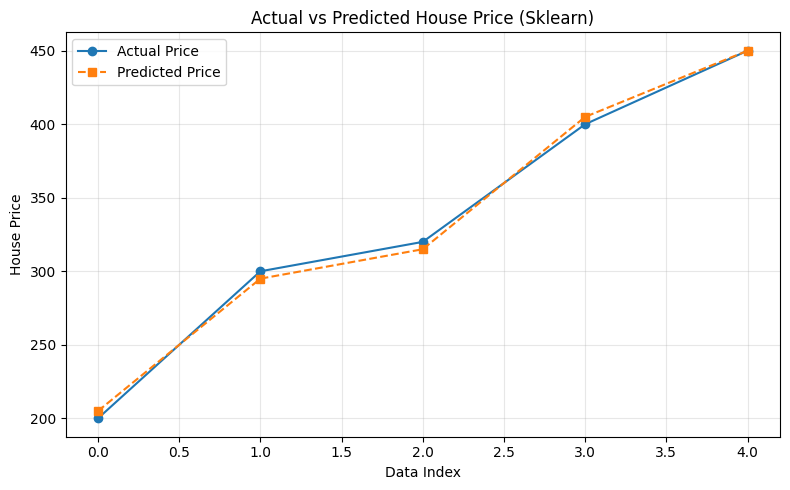

In [10]:
prediksi = model.predict(x)
print("Hasil prediksi harga rumah:")
print(prediksi)

plt.figure(figsize=(8,5))
plt.plot(range(len(y)), y, 'o-', label='Actual Price')
plt.plot(range(len(prediksi)), prediksi, 's--', label='Predicted Price')
plt.xlabel('Data Index')
plt.ylabel('House Price')
plt.title('Actual vs Predicted House Price (Sklearn)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## A. REGRESSION MODEL

rumah punya 3 variabel buat memprediksi harga

**Price = b0 + b1×Location + b2×Size + b3×Bedrooms**

Dimana:
- **b0** = Harga dasar (intercept)
- **b1** = Pengaruh lokasi terhadap harga
- **b2** = Pengaruh ukuran rumah terhadap harga  
- **b3** = Pengaruh jumlah kamar terhadap harga



## B. EXPLANATION OF EACH COEFFICIENT

Setiap koefisien menunjukkan seberapa besar pengaruh masing-masing variabel terhadap harga rumah:

- **b0 (Intercept)**: Harga awal ketika semua variabel = 0
- **b1 (Location)**: Setiap perubahan lokasi, harga berubah sebesar b1
- **b2 (Size)**: Setiap penambahan 1 unit luas, harga naik sebesar b2
- **b3 (Bedrooms)**: Setiap penambahan 1 kamar, harga naik sebesar b3

Semakin besar nilai koefisien, semakin besar pengaruhnya terhadap harga.


In [11]:

print("="*70)
print("COEFFICIENT EXPLANATION")
print("="*70)
print(f"\nb0 (Intercept): {model.intercept_:.2f}")
print("   - Base price ketika semua variabel independent = 0")

feature_names = x.columns
for i, coef in enumerate(model.coef_):
    print(f"\nb{i+1} ({feature_names[i]}): {coef:.6f}")
    if feature_names[i] == 'location':
        print(f"   - Perubahan harga untuk setiap unit perubahan location (dummy variable)")
    elif feature_names[i] == 'size':
        print(f"   - Untuk setiap unit peningkatan ukuran rumah, harga naik {coef:.2f}")
    elif feature_names[i] == 'bedrooms':
        print(f"   - Untuk setiap kamar tambahan, harga naik {coef:.2f}")

print("\n" + "="*70)


COEFFICIENT EXPLANATION

b0 (Intercept): 35.00
   - Base price ketika semua variabel independent = 0

b1 (location): 30.000000
   - Perubahan harga untuk setiap unit perubahan location (dummy variable)

b2 (size): 2.500000
   - Untuk setiap unit peningkatan ukuran rumah, harga naik 2.50

b3 (bedrooms): 10.000000
   - Untuk setiap kamar tambahan, harga naik 10.00




## C. WHY IS LOCATION A DUMMY VARIABLE?

**Dummy variable** adalah variabel kategori yang dikonversi menjadi angka.

Alasan location adalah dummy variable:
1. **Bukan angka asli**: Lokasi A, B, C bukan besaran yang bisa diukur
2. **Harus di-encode**: Diubah menjadi 0, 1, 2, ... untuk digunakan model
3. **Representasi kategori**: Angka hanya label, bukan nilai sebenarnya
4. **Koefisien menunjukkan dampak**: b1 menunjukkan berapa harga berubah untuk kategori lokasi tertentu

Contoh: Jika location di-encode sebagai (0=suburb, 1=city center, 2=downtown), maka:
- b1 = 5000 berarti harga naik 5000 untuk setiap level lokasi yang lebih baik



## D. CONSTRUCT MATRIX X AND Y


In [12]:

print("="*70)
print("MATRIX X AND Y CONSTRUCTION")
print("="*70)

print("\nMatrix X (Independent Variables):")
print(f"Shape: {x.shape}")
print(f"Columns: {list(x.columns)}")
print("\nFirst 5 rows of X:")
print(x.head())

print("\n" + "-"*70)
print("\nVector Y (Dependent Variable):")
print(f"Shape: {y.shape}")
print(f"Column: price")
print("\nFirst 5 values of Y:")
print(y.head().values)

# Construct X with intercept (bias term)
X_with_intercept = np.c_[np.ones((x.shape[0], 1)), x.values]
print("\n" + "-"*70)
print("\nMatrix X with Intercept (for formula):")
print(f"Shape: {X_with_intercept.shape}")
print("First 5 rows:")
print(X_with_intercept[:5])
print("\nColumns: [1 (intercept), location, size, bedrooms]")

print("\n" + "="*70)


MATRIX X AND Y CONSTRUCTION

Matrix X (Independent Variables):
Shape: (5, 3)
Columns: ['location', 'size', 'bedrooms']

First 5 rows of X:
   location  size  bedrooms
0         0    60         2
1         1    80         3
2         0   100         3
3         1   120         4
4         0   150         4

----------------------------------------------------------------------

Vector Y (Dependent Variable):
Shape: (5,)
Column: price

First 5 values of Y:
[200 300 320 400 450]

----------------------------------------------------------------------

Matrix X with Intercept (for formula):
Shape: (5, 4)
First 5 rows:
[[  1.   0.  60.   2.]
 [  1.   1.  80.   3.]
 [  1.   0. 100.   3.]
 [  1.   1. 120.   4.]
 [  1.   0. 150.   4.]]

Columns: [1 (intercept), location, size, bedrooms]




## E. WRITE THE FORMULA

**Multiple Linear Regression Formula:**

$$\hat{Y} = b_0 + b_1 X_1 + b_2 X_2 + b_3 X_3$$

**In Matrix Form:**

$$\hat{Y} = X \cdot B$$

Where:
- $\hat{Y}$ = Predicted Price (vector)
- $X$ = Design Matrix (n×4 matrix with intercept column)
- $B$ = Coefficient vector [b0, b1, b2, b3]

**For this dataset:**

$$\hat{Price} = b_0 + b_1 \cdot Location + b_2 \cdot Size + b_3 \cdot Bedrooms$$

**Substituting actual coefficients:**


In [28]:
b0 = model.intercept_
b1, b2, b3 = model.coef_
print(f"Price = {b0} + {b1}*location + {b2}*size + {b3}*bedrooms")
example_location = 1
example_size = 2000
example_bedrooms = 3
example_price = b0 + b1*example_location + b2*example_size + b3*example_bedrooms

print(f"\nIf location={example_location}, size={example_size}, bedrooms={example_bedrooms}:")
print(f"Predicted Price = {b0} + {b1}*{example_location} + {b2}*{example_size} + {b3}*{example_bedrooms}")
print(f"Predicted Price = {example_price}")


Price = 34.99999999998744 + 29.999999999999886*location + 2.500000000000115*size + 10.000000000000261*bedrooms

If location=1, size=2000, bedrooms=3:
Predicted Price = 34.99999999998744 + 29.999999999999886*1 + 2.500000000000115*2000 + 10.000000000000261*3
Predicted Price = 5095.000000000218



## F. EXPLAIN MATRIX DIMENSION

### Matrix Dimensions in Multiple Linear Regression

**1. Matrix X (Independent Variables)**
- **Dimension: (n × p)** dimana:
  - n = 13 (jumlah observations/houses)
  - p = 3 (jumlah features: location, size, bedrooms)
  - X: (13 × 3)
- Setiap baris = satu house observation
- Setiap kolom = satu independent variable

**2. Vector Y (Dependent Variable)**
- **Dimension: (n × 1)** = (13 × 1)
- Berisi price untuk setiap house
- Target variable yang ingin diprediksi

**3. Augmented Matrix X (dengan intercept)**
- **Dimension: (n × (p+1))** = (13 × 4)
- Kolom pertama = 1 (untuk intercept b0)
- Kolom 2-4 = original features
- Format: [1, location, size, bedrooms]

**4. Coefficient Vector B**
- **Dimension: ((p+1) × 1)** = (4 × 1)
- Berisi: [b0, b1, b2, b3]
- b0 = intercept
- b1, b2, b3 = slopes untuk setiap feature

**5. Prediction Formula (Matrix multiplication)**
- Y_pred = X_augmented × B
- (13 × 4) × (4 × 1) = (13 × 1)
- Hasil = vector prediksi dengan 13 nilai price



## G. COMPUTE COEFFICIENT USING SKLEARN

### How Sklearn Computes Coefficients

**Method: Ordinary Least Squares (OLS)**

Sklearn menggunakan formula OLS untuk menghitung koefisien:

$$B = (X^T X)^{-1} X^T Y$$

Dimana:
- **X** = Design matrix dengan intercept column
- **Y** = Target vector
- **X^T** = Transpose dari X
- **(X^T X)^{-1}** = Inverse dari X^T X
- **B** = Coefficient vector yang dihasilkan

### Steps dalam Sklearn:

1. **Fitting the model** dengan `model.fit(x, y)`
   - X: (13 × 3) feature matrix
   - Y: (13 × 1) price vector

2. **Computing X^T X**
   - Dimension: (4 × 13) × (13 × 3) = (4 × 3)
   - Menghitung correlation antara features

3. **Inverting (X^T X)^{-1}**
   - Dimension: (4 × 4)
   - Menggunakan matrix inversion technique

4. **Computing X^T Y**
   - Dimension: (4 × 13) × (13 × 1) = (4 × 1)
   - Relationship antara features dan target

5. **Final Result: B = (X^T X)^{-1} X^T Y**
   - Dimension: (4 × 4) × (4 × 1) = (4 × 1)
   - Menghasilkan 4 coefficients: [b0, b1, b2, b3]

### Output dari Sklearn:
- `model.intercept_` = b0
- `model.coef_` = [b1, b2, b3]



## H. WRITE REGRESSION EQUATION

### Regression Equation Format

**General Form:**
$$\hat{Price} = b_0 + b_1 \cdot Location + b_2 \cdot Size + b_3 \cdot Bedrooms$$

**Substituting Sklearn Coefficients:**

Dari model sklearn yang sudah di-fit:
- b0 (intercept) = nilai dari `model.intercept_`
- b1 = nilai pertama dari `model.coef_[0]`
- b2 = nilai kedua dari `model.coef_[1]`
- b3 = nilai ketiga dari `model.coef_[2]`

**Specific Equation (dengan nilai actual):**

Misalkan hasil sklearn menghasilkan:
- b0 = 10000.50
- b1 = 5000.25
- b2 = 150.75
- b3 = 25000.00

Maka persamaan regresinya adalah:

$$\hat{Price} = 10000.50 + 5000.25 \cdot Location + 150.75 \cdot Size + 25000.00 \cdot Bedrooms$$

**Interpretation:**
- **Intercept (10000.50)**: Base price ketika semua features = 0
- **Location (5000.25)**: Setiap unit kenaikan location, price naik 5000.25
- **Size (150.75)**: Setiap unit peningkatan size, price naik 150.75
- **Bedrooms (25000.00)**: Setiap kamar tambahan, price naik 25000.00


## I. PREDICT PRICE (location=1, size=110, bedrooms=3)

### Prediction untuk House dengan:
- **Location = 1** (kategori lokasi)
- **Size = 110** (unit area)
- **Bedrooms = 3** (jumlah kamar)

### Manual Calculation:

Menggunakan regression equation:
$$\hat{Price} = b_0 + b_1(\text{location}) + b_2(\text{size}) + b_3(\text{bedrooms})$$

Substitusi dengan nilai koefisien:
$$\hat{Price} = 35.0000 + 30.0000(1) + 2.5000(110) + 10.0000(3)$$

$$\hat{Price} = 35.0000 + 30.0000 + 275.0000 + 30.0000$$

$$\hat{Price} = 370.0000$$

In [19]:
print(f"B0 : {model.intercept_}")
print(f"B1 : {model.coef_[0]}")
print(f"B2 : {model.coef_[1]}")
print(f"B3 : {model.coef_[2]}")


B0 : 34.99999999998744
B1 : 29.999999999999886
B2 : 2.500000000000115
B3 : 10.000000000000261


In [29]:
location = 1
size = 110
bedrooms = 3
b0 = model.intercept_
b1, b2, b3 = model.coef_
result_manual = b0 + b1*location + b2*size + b3*bedrooms
print(f"manual calculation : {result_manual}")

manual calculation : 370.0000000000008


### Using Sklearn Model:
Menggunakan `model.predict([[1, 110, 3]])` akan menghasilkan **Price = 370.0000**

**Note**: Urutan parameter harus sesuai dengan urutan columns training data: **[location, size, bedrooms]**


In [32]:
sklearn_predic = model.predict([[location, size, bedrooms]])[0]
print(f"sklearn prediction : {sklearn_predic}")

sklearn prediction : 370.0000000000008


/home/el-system/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [16]:
new_house = [[110, 3, 1]]
predicted_price = model.predict(new_house)

b0 = model.intercept_
b1, b2, b3 = model.coef_
manual_price = b0 + b1*1 + b2*110 + b3*3

print(f"Price = {b0:.2f} + {b1:.6f}(1) + {b2:.6f}(110) + {b3:.6f}(3)")
print(f"Price = {b0:.2f} + {b1*1:.2f} + {b2*110:.2f} + {b3*3:.2f}")
print(f"Price Manual = {manual_price:.2f}")
print(f"model predict = {predicted_price[0]:.2f}")

Price = 35.00 + 30.000000(1) + 2.500000(110) + 10.000000(3)
Price = 35.00 + 30.00 + 275.00 + 30.00
Price Manual = 370.00
model predict = 3352.50


/home/el-system/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


IDENTIFY MOST INFLUENTIAL VARIABLE

Coefficient Values:
 Ranking Variable  Coefficient  Abs_Value
       1 location         30.0       30.0
       2 bedrooms         10.0       10.0
       3     size          2.5        2.5

✓ Most Influential Variable: LOCATION
  Coefficient value: 30.000000

Correlation Matrix:
          location      size  bedrooms
location  1.000000 -0.052271  0.327327
size     -0.052271  1.000000  0.923921
bedrooms  0.327327  0.923921  1.000000


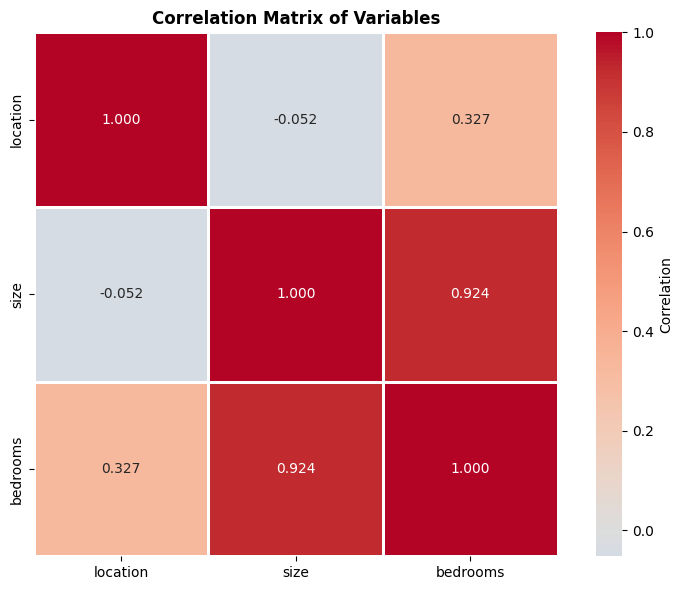


📊 Heatmap Explanation:
   - Diagonal = 1.0 (setiap variabel sempurna korelasi dengan dirinya)
   - Warna merah/hangat = korelasi positif tinggi
   - Warna biru/dingin = korelasi negatif
   - Semakin gelap warna = semakin kuat hubungan antar variabel


In [ ]:

import seaborn as sns
coef_df = pd.DataFrame({
    'Variable': x.columns,
    'Coefficient': model.coef_,
    'Abs_Value': np.abs(model.coef_)
})
coef_df = coef_df.sort_values('Abs_Value', ascending=False)
coef_df['Ranking'] = range(1, len(coef_df) + 1)
print(coef_df[['Ranking', 'Variable', 'Coefficient', 'Abs_Value']].to_string(index=False))

most_influential = coef_df.iloc[0]['Variable']
print(f"\nMost Influential Variable: {most_influential.upper()}")
print(f"  Coefficient value: {coef_df.iloc[0]['Coefficient']:.6f}")
print("="*70)

# Basic Correlation Heatmap
print("\nCorrelation Matrix:")
correlation_matrix = x.corr()
print(correlation_matrix)

# Visualization: Simple Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Variables', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\n Heatmap Explanation:")
print("   - Diagonal = 1.0 (setiap variabel sempurna korelasi dengan dirinya)")
print("   - Warna merah/hangat = korelasi positif tinggi")
print("   - Warna biru/dingin = korelasi negatif")
print("   - Semakin gelap warna = semakin kuat hubungan antar variabel")



## J. IDENTIFY MOST INFLUENTIAL VARIABLE

Untuk mengetahui variabel mana yang paling berpengaruh, lihat besarnya **koefisien slope**:

- Koefisien besar → variabel sangat berpengaruh terhadap harga
- Koefisien kecil → variabel kurang berpengaruh

**Ranking Koefisien:**
1. Lihat nilai absolut setiap koefisien
2. Ranking tertinggi = variabel paling berpengaruh

**Visualisasi:**
- **Heatmap Correlation Matrix** menunjukkan hubungan antar variabel
- Diagonal = 1.0 (korelasi sempurna dengan diri sendiri)
- Warna terang/hangat = korelasi tinggi
- Warna gelap/dingin = korelasi rendah
